# **Data Wrangling and Data Preprocessing**

Data wrangling and data preprocessing are closely related concepts in data science.  
They are often used interchangeably, but they are **not exactly the same**.

### **What is Data Wrangling?**

- Data wrangling is the process of **collecting, cleaning, organizing, and transforming raw data** into a usable format.
- It focuses on handling **messy, real-world data** and preparing it for analysis.
- Think of it as **“wrestling” data into shape** before it can be used.

Examples:
- Fixing missing or incorrect values  
- Merging multiple datasets  
- Renaming columns  
- Restructuring data (rows, columns, formats)

### **What is Data Preprocessing?**

- Data preprocessing is a **subset of data wrangling** that focuses on preparing data **specifically for machine learning or statistical models**.
- It emphasizes transforming data into a form that algorithms can understand.

Examples:
- Feature scaling and normalization  
- Encoding categorical variables  
- Handling outliers  
- Splitting data into training and testing sets  

### **How They Relate**

- **Data Wrangling = Big Picture**
  - Getting raw data into a usable and organized form

- **Data Preprocessing = Model Preparation**
  - Refining the data so models can learn effectively

### **Simple Way to Remember**

- **Data Wrangling:** “Make the data usable.”
- **Data Preprocessing:** “Make the data model-ready.”

### **Why Both Matter**

- Improve data quality  
- Increase model accuracy  
- Reduce errors and bias  
- Make analysis more reliable and efficient  

Without proper wrangling and preprocessing, even the best algorithms will produce poor results.


---

### 1. **Data Cleaning**

- Data cleaning is the process of detecting and correcting errors and inconsistencies in data to improve its quality. This phase ensures that the data is accurate, valid, consistent, relevant, and complete.

- Key Activities in Data Cleaning:

 - **Handling Missing Values**: Replacing, modifying, or deleting the missing or inconsistent data.
 - **Removing Duplicates**: Identifying and removing redundant data.
 - **Noise Reduction**: Smoothing out noisy data or outliers using techniques like binning.
 - **Error Correction**: Identifying and rectifying errors in the dataset.

---

### **2. Data Transformation**

- Data transformation is the process of converting data into a suitable format or structure for analysis. It involves the consolidation of datasets, normalization, and aggregation to prepare data for modeling.

- #### Key Activities in Data Transformation:

 - **Feature Scaling**: Standardizing the range of independent variables or features of the data.
 - **Encoding Categorical Values**: Converting non-numeric data into a format that can be provided to machine learning algorithms.
 - **Feature Engineering**: Creating new features from the existing data.
 - **Dimensionality Reduction**: Reducing the number of random variables under consideration by obtaining a set of principal variables.

---



## **Load the Dataset**

In [1]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the Dataset
df = pd.read_csv('/content/CustomerPurchaseProfile.csv')

In [3]:
# Overview of the Dataset
print("Dataset Overview:")
df.shape

Dataset Overview:


(1000, 9)

In [4]:
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,Name,age,Gender-Type,income-level,Country_name,product Purchase,Price-of_product,Review_Score,Membership Years
0,Person_0,53,Male,81550.0,USA,Item_C,801.785531,4.262518,7
1,Person_1,43,Male,31536.0,USA,Item_D,665.159955,8.415979,1
2,Person_2,29,Male,81550.0,Australia,Item_A,436.921531,2.836789,2
3,Person_3,57,Female,85681.0,Canada,Item_A,935.382616,5.221367,2
4,Person_4,22,Male,72269.0,UK,Item_C,581.855437,8.208448,5


In [5]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1000 non-null   object 
 1   age               950 non-null    object 
 2   Gender-Type       1000 non-null   object 
 3   income-level      961 non-null    float64
 4   Country_name      1000 non-null   object 
 5   product Purchase  990 non-null    object 
 6   Price-of_product  906 non-null    float64
 7   Review_Score      1000 non-null   float64
 8   Membership Years  1000 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [6]:
print("\nSummary Statistics:")
df.describe()


Summary Statistics:


,income-level,Price-of_product,Review_Score,Membership Years
count,961.000000,906.000000,1000.000000,1000.000000
mean,60707.239334,504.691311,5.488976,5.529000
std,22256.495224,281.195556,2.598629,2.884351
min,20207.000000,11.100973,1.008491,1.000000
25%,42443.000000,262.148141,3.274379,3.000000
50%,61568.000000,491.830940,5.368891,6.000000
75%,80428.000000,740.051825,7.676700,8.000000
max,99973.000000,999.562126,9.994153,10.000000


----

## 2. **Fixing Column Name Inconsistency**

   Column names in a dataset can often be inconsistent or difficult to work with, especially when they contain spaces, special characters, or a mix of uppercase and lowercase letters. Standardizing column names ensures better readability and usability when performing analysis.

   ### Objectives
   - **Remove spaces and special characters** from column names.
   - **Convert column names to lowercase** for consistency.
   - **Rename specific columns** to improve clarity and understanding.

 **Step 1: Inspect Column Names**

Task: View the current column names to identify inconsistencies.

In [7]:
# Display the current column names
df.columns

Index(['Name', 'age', 'Gender-Type', 'income-level', 'Country_name',
       'product Purchase', 'Price-of_product', 'Review_Score',
       'Membership Years'],
      dtype='object')

**Step 2: Remove Spaces and Special Characters**

Spaces and special characters can create problems when referencing columns. Use str.replace to replace these with underscores.

In [8]:
# Replace spaces and special characters with underscores
df.columns = df.columns.str.replace(' ', '_').str.replace('-', '_')

In [9]:
print("\nColumn Names After Replacing Spaces and Special Characters:")
df.columns


Column Names After Replacing Spaces and Special Characters:


Index(['Name', 'age', 'Gender_Type', 'income_level', 'Country_name',
       'product_Purchase', 'Price_of_product', 'Review_Score',
       'Membership_Years'],
      dtype='object')

**Step 3: Convert Column Names to Lowercase**

Converting all column names to lowercase ensures uniformity and avoids issues in case-sensitive systems.

In [10]:
# Convert all column names to lowercase
df.columns = df.columns.str.lower()

In [11]:
print("\nColumn Names After Converting to Lowercase:")
df.columns


Column Names After Converting to Lowercase:


Index(['name', 'age', 'gender_type', 'income_level', 'country_name',
       'product_purchase', 'price_of_product', 'review_score',
       'membership_years'],
      dtype='object')

**Step 4: Rename Columns for Clarity**

Renaming specific columns can make them more descriptive and easier to understand and handel.

In [12]:
# Rename specific columns for clarity
df.rename(columns={
    'gender_type': 'gender',
    'product_purchase': 'product',
    'price_of_product': 'price',
    'membership_years': 'membership_duration'
}, inplace=True)

In [13]:
print("\nColumn Names After Renaming for Clarity:")
df.columns


Column Names After Renaming for Clarity:


Index(['name', 'age', 'gender', 'income_level', 'country_name', 'product',
       'price', 'review_score', 'membership_duration'],
      dtype='object')

## 3. **Fixing Data Mis-types**

   Data types define the kind of data that can be stored in a column. Inconsistent or incorrect data types can cause errors during analysis or modeling. This step ensures all columns have the appropriate data types, enabling smoother processing and analysis.

   ### Objectives
   - **Identify columns with incorrect or inconsistent data types.**
   - **Convert the `age` column from object to numeric.**
   - **Ensure numerical columns like `income_level` and `price_of_product` are consistent `float64` types.**
   - **Validate categorical values for typos and inconsistencies.**


**Step 1: Inspect Current Data Types**

Task: Review the current data types of all columns in the dataset.

In [14]:
# Inspect data types of columns
print("Current Data Types:")
df.dtypes

Current Data Types:


,0
name,object
age,object
gender,object
income_level,float64
country_name,object
product,object
price,float64
review_score,float64
membership_duration,int64


**Observe which columns have unexpected types.**
- Example: `age` is `object` instead of `int64`.
- Columns like `income_level` or `price_of_product` should be `float64`.


In [15]:
df['age'].unique()

array(['53', '43', '29', '57', '22', nan, '33', '37', '25', '38', '50',
       '54', '36', '16', '58', '44', '?', '35', '47', '26', '39', '63',
       '41', '56', '42', '61', '17', '21', '23', '32', '28', '64', '40',
       '34', '49', '31', '20', '18', '48', '24', '45', '62', '30', '59',
       '55', '15', '19', '51', '27', '46', '52', '60'], dtype=object)

In [16]:
# Replace non-numeric characters with NaN for the 'age' column
# In our case, we are specifically replacing '?' with NaN, directly in the DataFrame
df.replace({'age':'?'}, np.nan, inplace=True)

In [17]:
df['age'].unique()

array(['53', '43', '29', '57', '22', nan, '33', '37', '25', '38', '50',
       '54', '36', '16', '58', '44', '35', '47', '26', '39', '63', '41',
       '56', '42', '61', '17', '21', '23', '32', '28', '64', '40', '34',
       '49', '31', '20', '18', '48', '24', '45', '62', '30', '59', '55',
       '15', '19', '51', '27', '46', '52', '60'], dtype=object)

In [18]:
df['age'] = pd.to_numeric(df['age'])

In [19]:
df.dtypes

,0
name,object
age,float64
gender,object
income_level,float64
country_name,object
product,object
price,float64
review_score,float64
membership_duration,int64


**Step 4: Validate Categorical Values for Typos**

Categorical columns like `gender_type` or `country_name` may contain unexpected values due to typos or inconsistencies.

In [20]:
# Check unique values in the gender column
print("Unique Values in Gender Column:")
df['gender'].unique()

Unique Values in Gender Column:


array(['Male', 'Female'], dtype=object)

Task: Correct inconsistencies in the `gender` column:

**Step 5: Verify Changes**

Task: Check that all corrections have been applied successfully.

In [21]:
# Verify corrected data types
print("\nData Types After Fixing:")
df.dtypes


Data Types After Fixing:


,0
name,object
age,float64
gender,object
income_level,float64
country_name,object
product,object
price,float64
review_score,float64
membership_duration,int64


In [22]:
# Check for invalid entries in gender
print("\nUnique Values in Gender (After Fixing):")
df['gender'].unique()


Unique Values in Gender (After Fixing):


array(['Male', 'Female'], dtype=object)

## 4. **Handling Missing Values**

Missing values are a common issue in raw datasets and can significantly impact analysis and modeling. This step focuses on detecting, visualizing, and handling missing values effectively using various strategies.

### Objectives
- **Detect missing values** in the dataset and visualize their distribution.
- **Apply strategies to handle missing values:**
  - Fill with mean, median, or mode.
  - Use forward-fill or backward-fill for time-series data.
  - Drop rows or columns with excessive missing values.
- **Use tools like `missingno` for visualization and `SimpleImputer` for automated handling of missing data.**


**Step 1: Detecting Missing Values**
Explanation:

- Missing values are represented as NaN in Pandas.
- Use `isnull()` and `sum()` to detect missing values across the dataset.

In [23]:
# Detect missing values
print("\nMissing Values Count in Each Column:")
df.isnull().sum()


Missing Values Count in Each Column:


,0
name,0
age,96
gender,0
income_level,39
country_name,0
product,10
price,94
review_score,0
membership_duration,0


<Axes: >

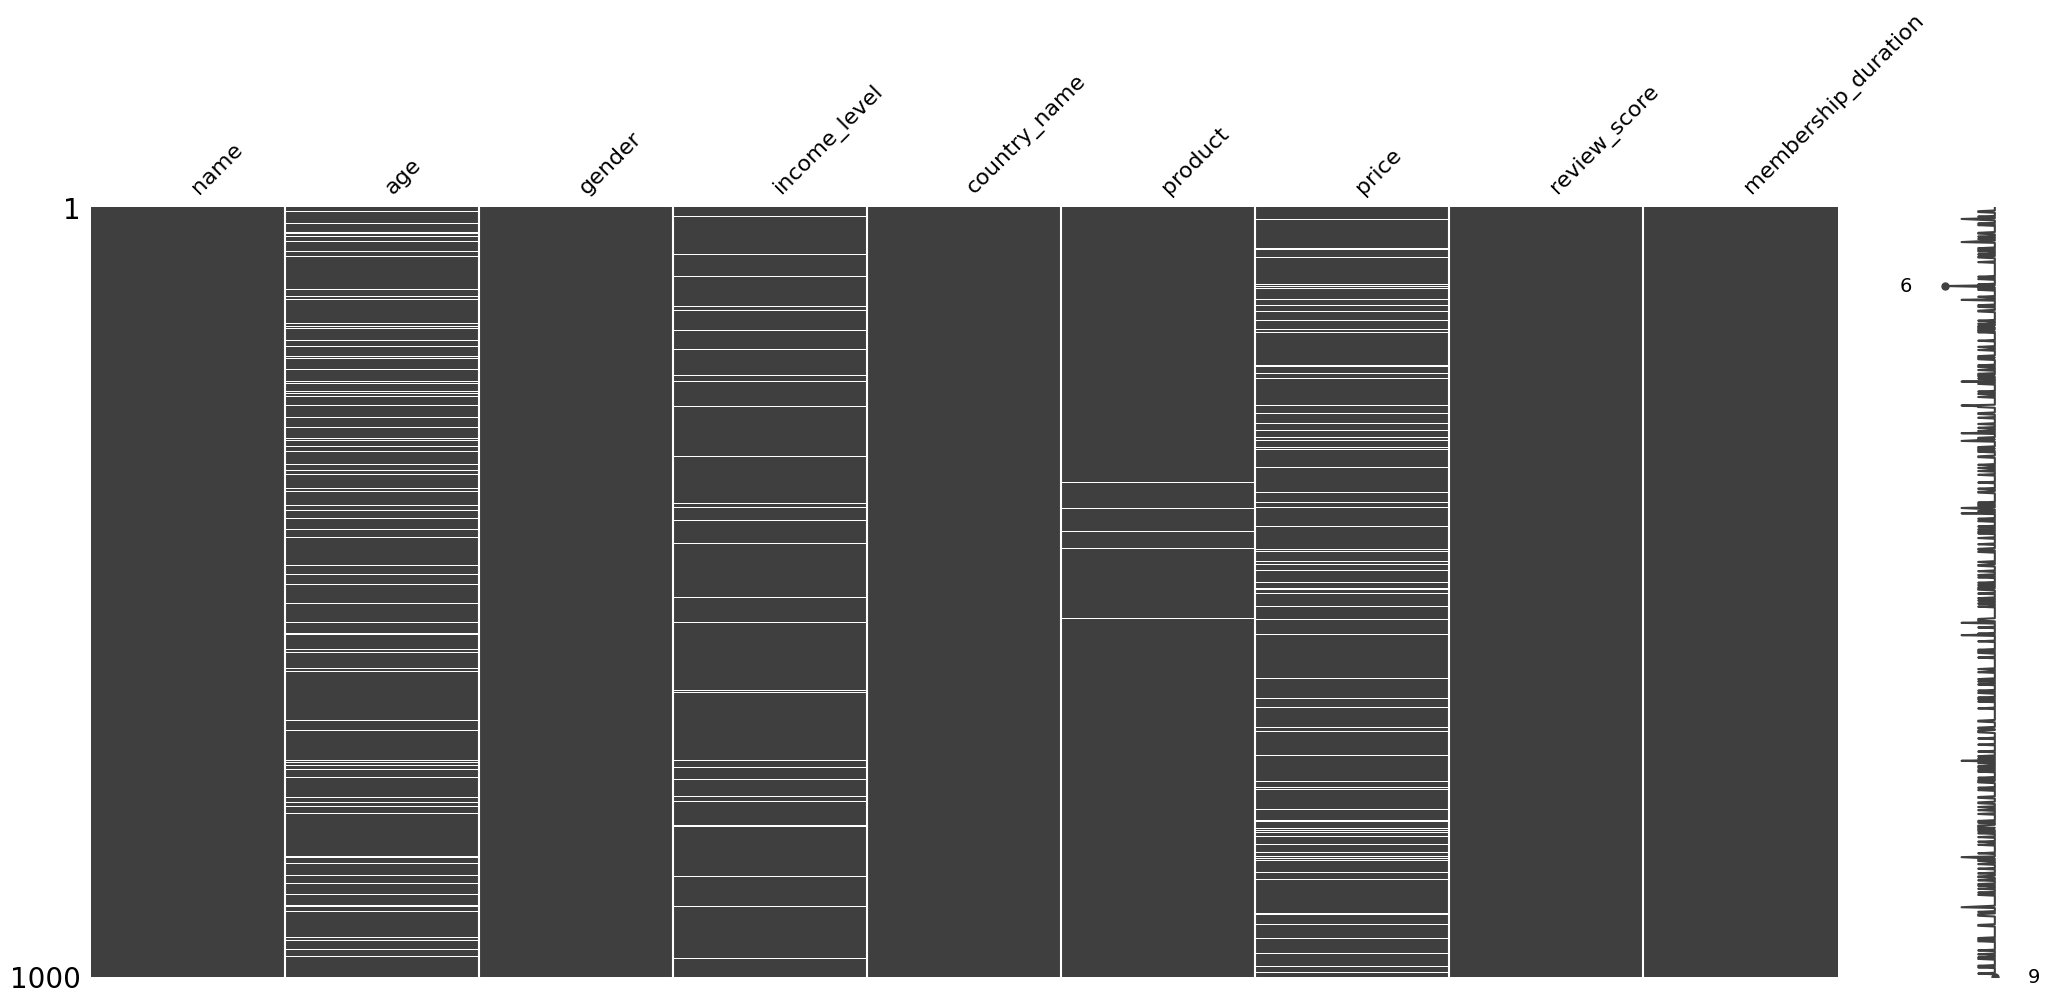

In [24]:
import missingno as msno

# Visualize missing data

msno.matrix(df)

<Axes: >

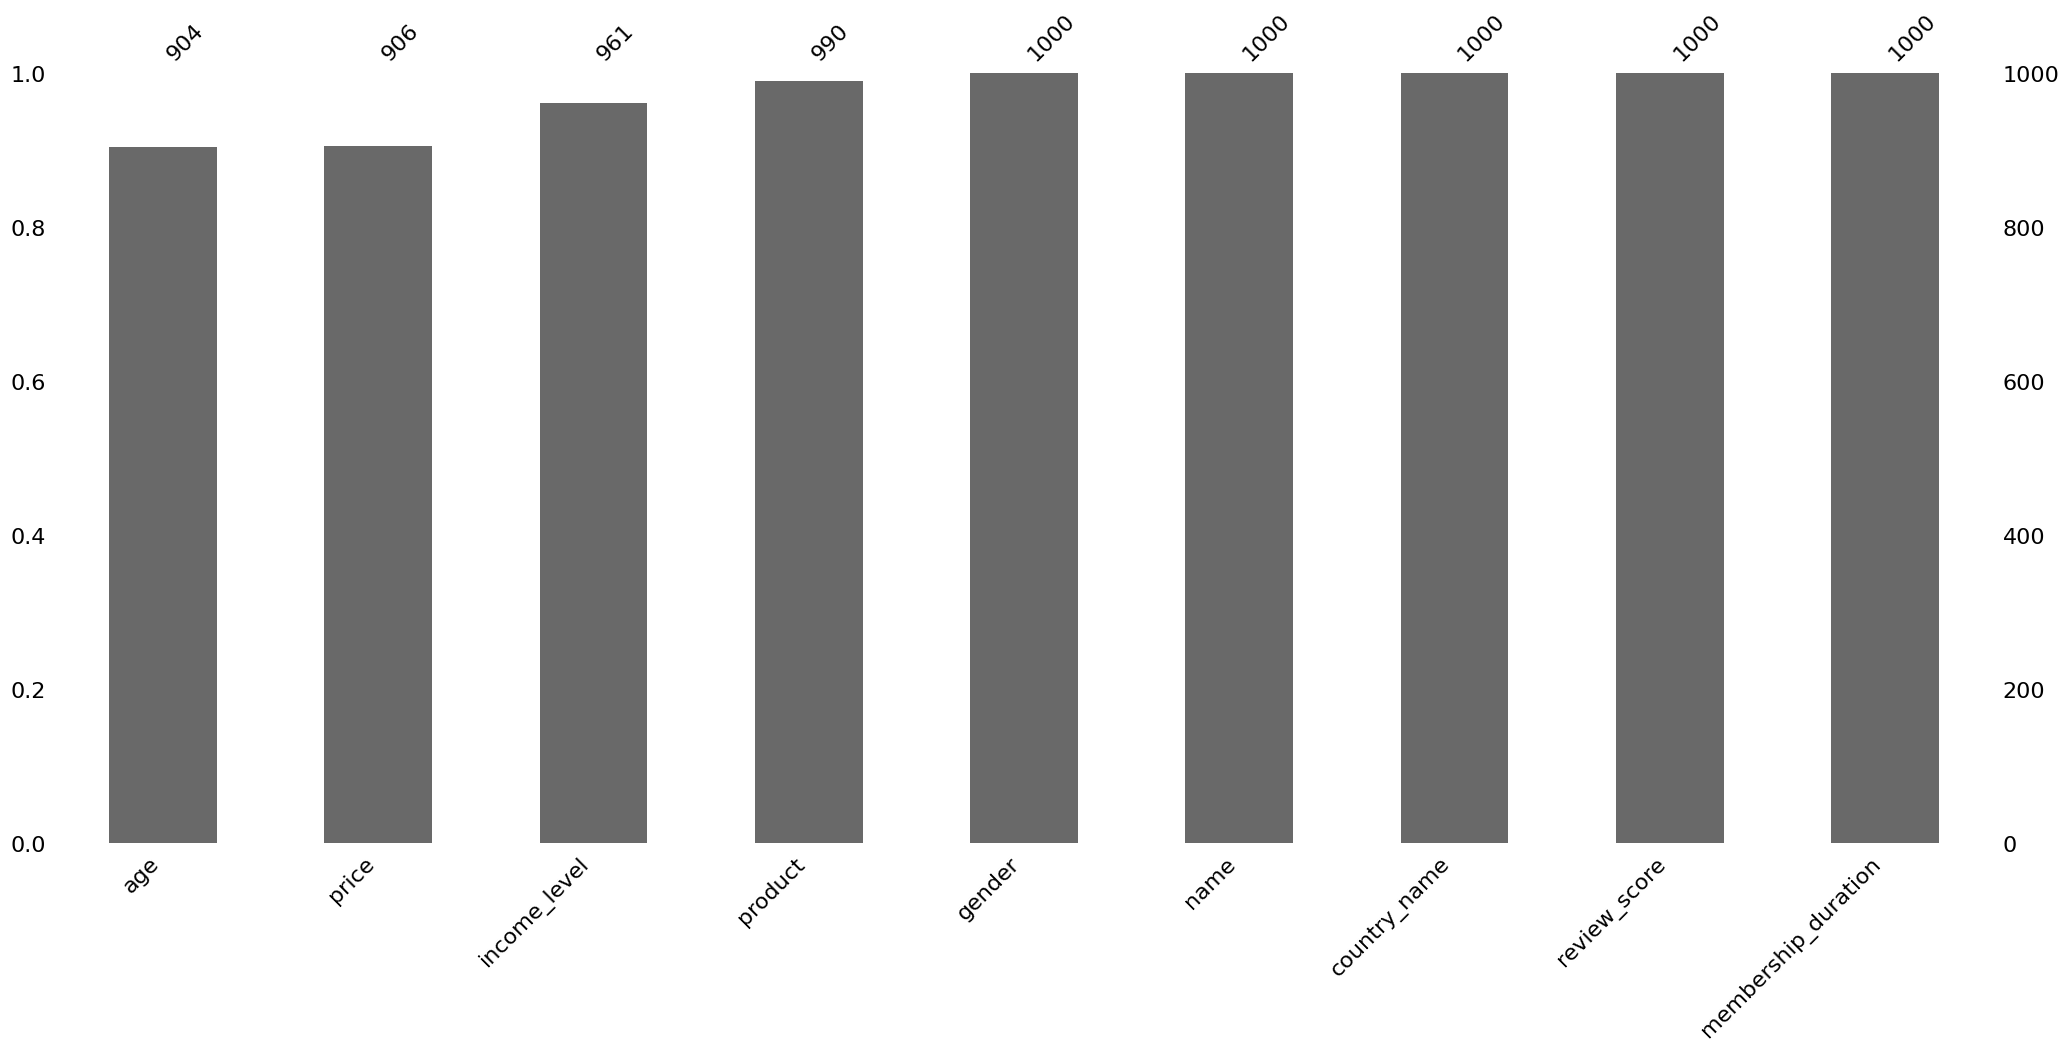

In [25]:
msno.bar(df, sort='ascending')

**Step 2: Filling Missing Values with Mean, Median, or Mode**


- **Mean:** Use for numerical data when the distribution is approximately normal.
- **Median:** Use for numerical data when the distribution is skewed.
- **Mode:** Use for categorical data.

In [26]:
# Filling missing values for multiple columns directly in the DataFrame
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)

In [27]:
income_level_mean = df['income_level'].mean()
df['income_level'] = df['income_level'].fillna(income_level_mean)

In [28]:
df['product'].mode()

,product
0,Item_C


In [29]:
# Filling missing values for 'price' and 'product' column
price_of_product_mean = df['price'].mean()
product_mode = df['product'].mode()[0]

df['price'] = df['price'].fillna(price_of_product_mean)
df['product'] = df['product'].fillna(product_mode)

**Step 3: Verifying Changes**

In [30]:
# Verify no missing values remain
print("Missing Values After Handling:")

df.isnull().sum()

Missing Values After Handling:


,0
name,0
age,0
gender,0
income_level,0
country_name,0
product,0
price,0
review_score,0
membership_duration,0


In [31]:
df.head()

,name,age,gender,income_level,country_name,product,price,review_score,membership_duration
0,Person_0,53.0,Male,81550.0,USA,Item_C,801.785531,4.262518,7
1,Person_1,43.0,Male,31536.0,USA,Item_D,665.159955,8.415979,1
2,Person_2,29.0,Male,81550.0,Australia,Item_A,436.921531,2.836789,2
3,Person_3,57.0,Female,85681.0,Canada,Item_A,935.382616,5.221367,2
4,Person_4,22.0,Male,72269.0,UK,Item_C,581.855437,8.208448,5


In [32]:
# Drop the 'name' column
df = df.drop(columns=['name'])

In [33]:
df.head()

,age,gender,income_level,country_name,product,price,review_score,membership_duration
0,53.0,Male,81550.0,USA,Item_C,801.785531,4.262518,7
1,43.0,Male,31536.0,USA,Item_D,665.159955,8.415979,1
2,29.0,Male,81550.0,Australia,Item_A,436.921531,2.836789,2
3,57.0,Female,85681.0,Canada,Item_A,935.382616,5.221367,2
4,22.0,Male,72269.0,UK,Item_C,581.855437,8.208448,5


In [34]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['gender', 'country_name', 'product'], drop_first = True).astype(int)

In [35]:
df_encoded.head()

,age,income_level,price,review_score,membership_duration,gender_Male,country_name_Canada,country_name_UK,country_name_USA,product_Item_B,product_Item_C,product_Item_D
0,53,81550,801,4,7,1,0,0,1,0,1,0
1,43,31536,665,8,1,1,0,0,1,0,0,1
2,29,81550,436,2,2,1,0,0,0,0,0,0
3,57,85681,935,5,2,0,1,0,0,0,0,0
4,22,72269,581,8,5,1,0,1,0,0,1,0


In [36]:
# Standarization
from sklearn.preprocessing import StandardScaler

In [37]:
# Initialize the scaler
scaler = StandardScaler()

In [38]:
scaler.fit_transform(df_encoded)

array([[ 0.96510638,  0.95579123,  1.10960091, ..., -0.57427105,
         1.65690022, -0.55270519],
       [ 0.23085016, -1.33771116,  0.60119784, ..., -0.57427105,
        -0.60353664,  1.80928281],
       [-0.79710855,  0.95579123, -0.25486321, ..., -0.57427105,
        -0.60353664, -0.55270519],
       ...,
       [ 1.40566011, -1.21508898,  0.29092244, ...,  1.74133801,
        -0.60353664, -0.55270519],
       [-1.45793915,  0.07028855, -0.3258901 , ..., -0.57427105,
         1.65690022, -0.55270519],
       [ 0.81825513,  0.62117119,  0.88156718, ..., -0.57427105,
        -0.60353664, -0.55270519]])

In [39]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns.tolist())

In [40]:
df_scaled.head()

,age,income_level,price,review_score,membership_duration,gender_Male,country_name_Canada,country_name_UK,country_name_USA,product_Item_B,product_Item_C,product_Item_D
0,0.965106,0.955791,1.109601,-0.382373,0.510249,0.949284,-0.554247,-0.575811,1.661144,-0.574271,1.656900,-0.552705
1,0.230850,-1.337711,0.601198,1.167266,-1.570983,0.949284,-0.554247,-0.575811,1.661144,-0.574271,-0.603537,1.809283
2,-0.797109,0.955791,-0.254863,-1.157193,-1.224111,0.949284,-0.554247,-0.575811,-0.601995,-0.574271,-0.603537,-0.552705
3,1.258809,1.145227,1.610527,0.005036,-1.224111,-1.053425,1.804250,-0.575811,-0.601995,-0.574271,-0.603537,-0.552705
4,-1.311088,0.530190,0.287184,1.167266,-0.183495,0.949284,-0.554247,1.736682,-0.601995,-0.574271,1.656900,-0.552705


In [41]:
df_final_preprocessed = df_scaled.copy()

In [42]:
df_final_preprocessed.to_csv('df_final_preprocessed.csv', index=False)